# Assignment 5

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional notes:

* Please note that in this assignment, students are expected to work independently. As a result, no two solutions should look identical in terms of coding;
* You may import any libraries you need to complete the assignment. However, you must implement the model using TensorFlow (do not use PyTorch);
* Follow the same steps/idea as in Assignment 4; the difference here is that you extend a logistic model to more than two classes;
* <span style="color:chocolate"> Focus on the execution of the task rather than model performance </span> (this is how the TA will grade your work);
* Even though the prediction performance for your chosen outcome is low, it doesn't necessarily mean there is something wrong with your implementation. It could also be that the data is not supportive enough for your prediction task... again, focus on the learning opportunity and not the numbers you get;
* Your instructional team has extensive experience developing and running ML models. Often, we encounter situations where a model doesn't perform well on a predictive task. This can happen due to the nature of the data or the need for significant tweaking of variables to achieve good results;
* Do not spend significantly more time on this task than you did on Assignment 4, unless you wish to experiment and learn more.
---

``Objective``
* Perform multiclass classification using logistic regression. <span style="color:chocolate"> You will choose the outcome of interest. </span>

``Motivation``
* Chocolate is one of the most popular candies in the world. Each year, residents of the United States collectively eat more than 2.8 billions pounds (Source: Kaggle). However, not all chocolate bars are created equal! In this assignment, you will have the opportunity to delve into the world of chocolate by choosing your own machine learning task. 


``Data``

* The [Chocolate Bar dataset](https://www.kaggle.com/datasets/rtatman/chocolate-bar-ratings) contains expert ratings of 1,795 individual chocolate bars, along with information on their regional origin, percentage of cocoa, the variety of chocolate bean used and where the beans were grown (Source: Kaggle).

### Import libraries

In [1]:
%pip install keras-tuner
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install tensorflow

%reset -f
from __future__ import print_function

import math
import numpy as np
import numpy.linalg as nla
import pandas as pd
import re
import six
from os.path import join
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from keras_tuner import HyperParameters

# feel free to import other libraries as needed
import seaborn as sns
from sklearn.metrics import accuracy_score, log_loss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


2026-02-16 07:56:45.433838: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-16 07:56:45.434324: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-16 07:56:45.506798: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 07:56:47.485523: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

### Define functions

In [2]:
def read_data():
    ''''''
    # Read data
    df = pd.read_csv(
        "https://download.mlcc.google.com/mledu-datasets/flavors_of_cacao.csv",
        sep=",",
        encoding='latin-1'
    )
    
    return df

In [3]:
def clean_data(df):
    ''''''
    # Set the output display to have one digit for decimal places and limit it to
    # printing 15 rows.
    pd.options.display.float_format = '{:.2f}'.format
    pd.options.display.max_rows = 15
    
    # Rename the columns.
    df.columns = [
        'maker', 'specific_origin', 'reference_number',
        'review_date', 'cocoa_percent', 'maker_location',
        'rating', 'bean_type', 'broad_origin'
    ]

    # df.dtypes

    # Replace empty/null values with "Blend"
    df['bean_type'] = df['bean_type'].fillna('Blend')

    # Cast bean_type to string to remove leading 'u'
    df['bean_type'] = df['bean_type'].astype(str)
    df['cocoa_percent'] = df['cocoa_percent'].str.strip('%')
    df['cocoa_percent'] = pd.to_numeric(df['cocoa_percent'])

    # Correct spelling mistakes, and replace city with country name
    df['maker_location'] = df['maker_location']\
    .str.replace('Amsterdam', 'Holland')\
    .str.replace('U.K.', 'England')\
    .str.replace('Niacragua', 'Nicaragua')\
    .str.replace('Domincan Republic', 'Dominican Republic')

    # Adding this so that Holland and Netherlands map to the same country.
    df['maker_location'] = df['maker_location']\
    .str.replace('Holland', 'Netherlands')

    def cleanup_spelling_abbrev(text):
        replacements = [
            ['-', ', '], ['/ ', ', '], ['/', ', '], ['\(', ', '], [' and', ', '], [' &', ', '], ['\)', ''],
            ['Dom Rep|DR|Domin Rep|Dominican Rep,|Domincan Republic', 'Dominican Republic'],
            ['Mad,|Mad$', 'Madagascar, '],
            ['PNG', 'Papua New Guinea, '],
            ['Guat,|Guat$', 'Guatemala, '],
            ['Ven,|Ven$|Venez,|Venez$', 'Venezuela, '],
            ['Ecu,|Ecu$|Ecuad,|Ecuad$', 'Ecuador, '],
            ['Nic,|Nic$', 'Nicaragua, '],
            ['Cost Rica', 'Costa Rica'],
            ['Mex,|Mex$', 'Mexico, '],
            ['Jam,|Jam$', 'Jamaica, '],
            ['Haw,|Haw$', 'Hawaii, '],
            ['Gre,|Gre$', 'Grenada, '],
            ['Tri,|Tri$', 'Trinidad, '],
            ['C Am', 'Central America'],
            ['S America', 'South America'],
            [', $', ''], [',  ', ', '], [', ,', ', '], ['\xa0', ' '],[',\s+', ','],
            [' Bali', ',Bali']
        ]
        for i, j in replacements:
            text = re.sub(i, j, text)
        return text

    df['specific_origin'] = df['specific_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Cast specific_origin to string
    df['specific_origin'] = df['specific_origin'].astype(str)

    # Replace null-valued fields with the same value as for specific_origin
    df['broad_origin'] = df['broad_origin'].fillna(df['specific_origin'])

    # Clean up spelling mistakes and deal with abbreviations
    df['broad_origin'] = df['broad_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Change 'Trinitario, Criollo' to "Criollo, Trinitario"
    # Check with df['bean_type'].unique()
    df.loc[df['bean_type'].isin(['Trinitario, Criollo']),'bean_type'] = "Criollo, Trinitario"
    # Confirm with df[df['bean_type'].isin(['Trinitario, Criollo'])]

    # Fix chocolate maker names
    df.loc[df['maker']=='Shattel','maker'] = 'Shattell'
    df['maker'] = df['maker'].str.replace(u'Na\xef\xbf\xbdve','Naive')

    return df

---
### Step 1: Data ingestion

First, we'll initiate the process of discovering the chocolate world by loading the data. Then, to assist with this assignment, we'll start by tidying up the data a little bit. This involves renaming columns and conducting some string preprocessing tasks, which will be handled by the <span style="color:chocolate">clean_data()</span> function mentioned earlier.

In [4]:
df = clean_data(read_data())
print('Shape of data', df.shape)
df.head()

Shape of data (1795, 9)


,maker,specific_origin,reference_number,review_date,cocoa_percent,maker_location,rating,bean_type,broad_origin
0,A. Morin,Agua Grande,1876,2016,63.00,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,1676,2015,70.00,France,2.75,Blend,Togo
2,A. Morin,Atsane,1676,2015,70.00,France,3.00,Blend,Togo
3,A. Morin,Akata,1680,2015,70.00,France,3.50,Blend,Togo
4,A. Morin,Quilla,1704,2015,70.00,France,3.50,Blend,Peru


### <span style="color:chocolate">Exercise 1:</span> Getting to know the data (5 points)

Answer the following questions:
    
1. How many columns does the dataset contain?
2. How many rows are there in the dataset?
3. What are the column names?
4. List the number of unique values for each column in the data;
5. What are the unique cocoa_percent values?

In [5]:
# 1. Data set contains 9 columns
# 2. Data set contains 1795 rows
# 3. Column names are maker, specific_origin, reference_number, review_date, cocoa_percent, maker_location, rating, bean_type, and broad_origin
# 4. Count of unique values for each column:
# maker                414
# specific_origin     1038
# reference_number     440
# review_date           12
# cocoa_percent         45
# maker_location        58
# rating                13
# bean_type             39
# broad_origin         160
# 5. Unique cocoa percent values:
# 63.   70.   60.   80.   88.   72.   55.   75.   65.   85.   73.   64.
# 66.   68.   50.  100.   77.   90.   71.   83.   78.   74.   76.   86.
# 82.   69.   91.   42.   61.   73.5  62.   67.   58.   60.5  79.   81.
# 57.   72.5  56.   46.   89.   99.   84.   53.   87.

### <span style="color:chocolate">Exercise 2:</span> Choosing the prediction task (5 points)

Now that you’ve explored the data, choose a multiclass outcome (anything except "ratings") that you’re interested in predicting. Note: The outcome should have <span style="color:chocolate">at least 3 classes</span>!

If your chosen outcome variable requires preprocessing, go ahead and handle that below. For instance, you might choose to predict "cocoa_percent". Discretizing it into "0=low," "1=medium," and "2=high" makes it easier to work with/interpret the results.

Your answer here: 

In [6]:
# I choose cocoa_percent

def preprocess_data(df):
    data = df.copy()

    cocoa_category_definition = [
        (data['cocoa_percent'] < 70),
        (data['cocoa_percent'] >= 70) & (data['cocoa_percent'] < 85),
        (data['cocoa_percent'] >= 85)
    ]
    cocoa_categories = [0, 1, 2]
    
    data['categorized_cocoa_percent'] = np.select(cocoa_category_definition, cocoa_categories)
    
    return data

---
### Step 2: Data preprocessing

### <span style="color:chocolate">Exercise 3:</span> Prepare data for modeling (20 points)

Following the format of previous assignments, adhere to the following steps as a minimum:

1. Shuffle the dataset;
2. Create training, validation, and test datasets using a 60/20/20 split;
3. Identify the features of interest;
4. Perform necessary cleaning and standarization on the features.

In [7]:
from sklearn.preprocessing import StandardScaler

df_preprocessed = preprocess_data(df)
df_preprocessed = df_preprocessed.sample(frac=1, random_state=0).reset_index(drop=True)


# I think country matters, but I don't want to have examine individual countries that only produce 1 batch because that seems like it may not be enough to get a good reading, so I group all these together as Other
origin_counts = df_preprocessed['broad_origin'].value_counts()
origin_counts_filtered = origin_counts[origin_counts >= 2]
print(origin_counts_filtered)
filtered_origins = origin_counts_filtered.index

df_preprocessed['broad_origin_cleaned'] = df_preprocessed['broad_origin'].apply(
    lambda x: x if x in filtered_origins else 'Other'
)

train_df, df_remaining_split = train_test_split(df_preprocessed, train_size=0.6, random_state=0)
val_df, test_df = train_test_split(df_remaining_split, test_size=0.5, random_state=0)

# I think rating is important for obvious reasons and I want to use broad_origin because I think the location matters
# rating
# broad_origin (cleaned)

scaler = StandardScaler()
X_train_rating = scaler.fit_transform(train_df[['rating']])
X_val_rating = scaler.transform(val_df[['rating']])
X_test_rating = scaler.transform(test_df[['rating']])

# do hot encoding for broad_origin_cleaned
train_ohe = pd.get_dummies(train_df['broad_origin_cleaned'])
val_ohe = pd.get_dummies(val_df['broad_origin_cleaned']).reindex(columns=train_ohe.columns, fill_value=0)
test_ohe = pd.get_dummies(test_df['broad_origin_cleaned']).reindex(columns=train_ohe.columns, fill_value=0)

X_train = np.hstack([X_train_rating, train_ohe.values])
X_val = np.hstack([X_val_rating, val_ohe.values])
X_test = np.hstack([X_test_rating, test_ohe.values])

Y_train = train_df['categorized_cocoa_percent'].values
Y_val = val_df['categorized_cocoa_percent'].values
Y_test = test_df['categorized_cocoa_percent'].values

broad_origin
Venezuela             214
Ecuador               193
Dominican Republic    166
Peru                  165
Madagascar            146
                     ... 
Noir                    2
El Salvador             2
Dark                    2
Blend No 1              2
Semisweet               2
Name: count, Length: 61, dtype: int64


---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 4:</span> Plots (20 points)

In line with the structure of previous assignments, execute the following steps:

1. Generate a minimum of 4 plots to investigate features and outcome within the training dataset;
2. Ensure that each plot includes clear axis labels and titles;
3. Provide commentary on the insights learned from your visualizations.

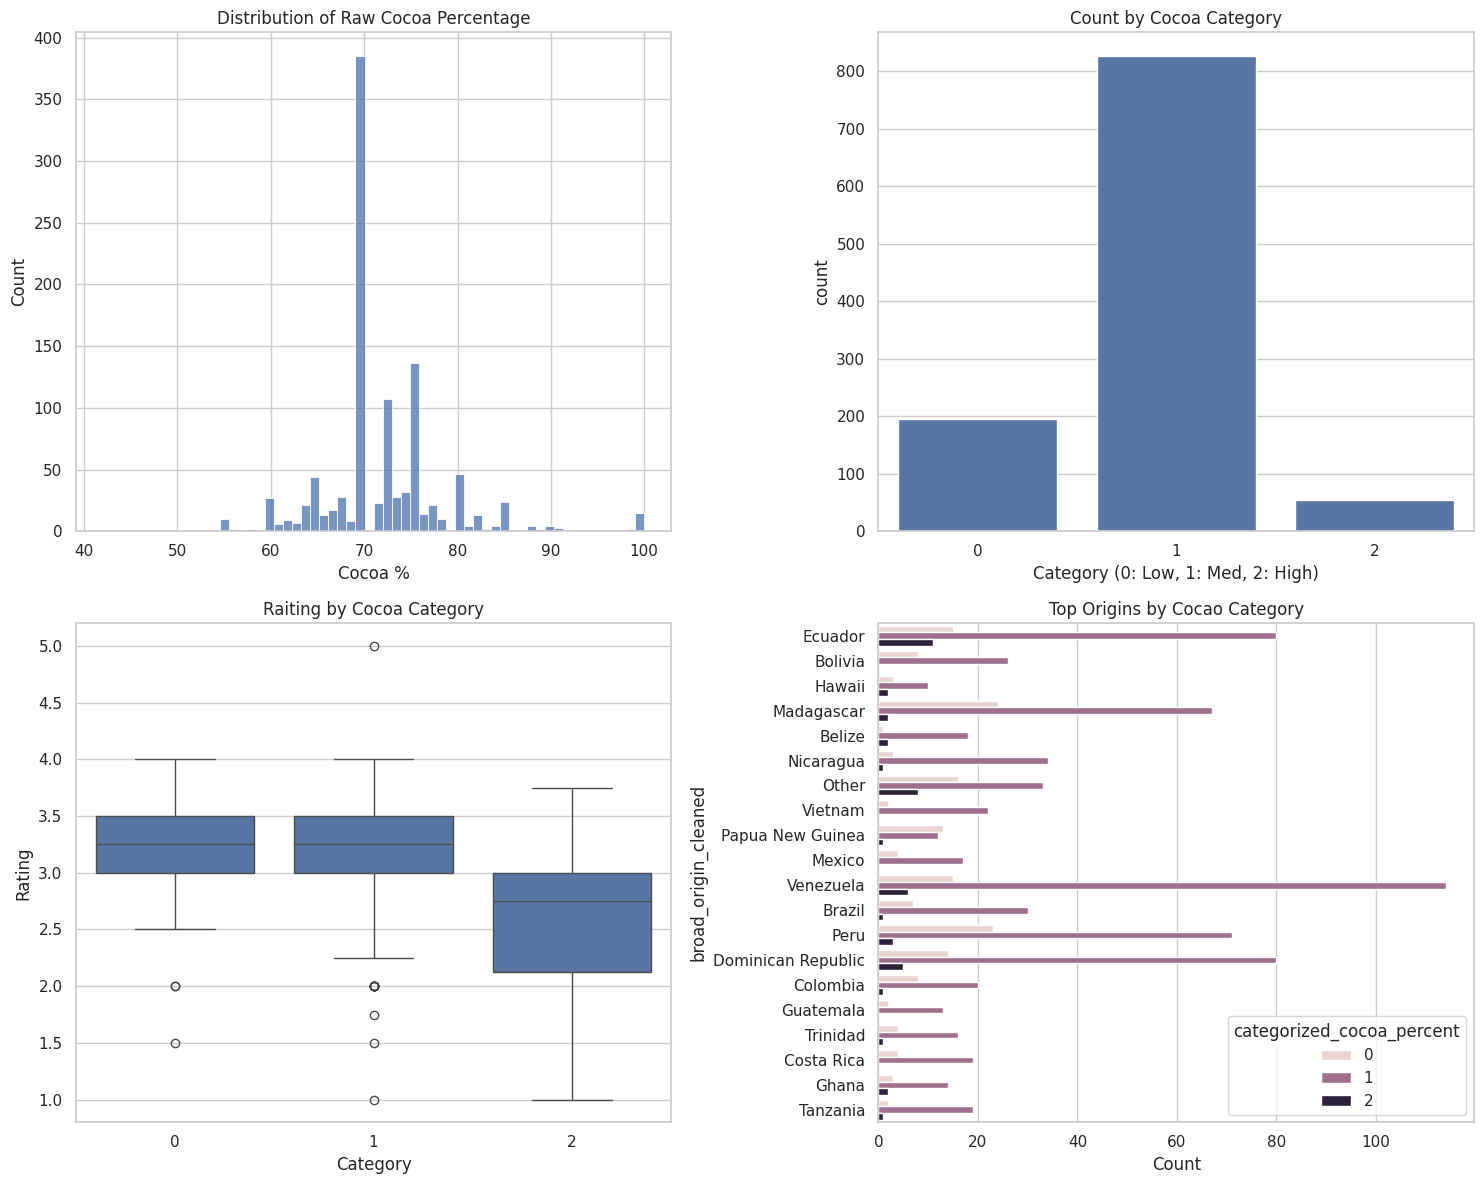

In [8]:
def generate_eda_plots(df):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Distribution of cacao percentage for me to visually check that my categories make sense.
    sns.histplot(df['cocoa_percent'], ax=axes[0,0])
    axes[0,0].set_title('Distribution of Raw Cocoa Percentage')
    axes[0,0].set_xlabel('Cocoa %')

    
    # See the type of cocoa category. This gives me a sense of how common each category is.
    sns.countplot(x='categorized_cocoa_percent', data=df, ax=axes[0,1])
    axes[0,1].set_title('Count by Cocoa Category')
    axes[0,1].set_xlabel('Category (0: Low, 1: Med, 2: High)')
    
    # See how the ratings relate to cocoa category. Very surprisingly, the higher-content has lower rating because I love dark chocolate and dark chocolate is more expensive.
    sns.boxplot(x='categorized_cocoa_percent', y='rating', data=df, ax=axes[1,0])
    axes[1,0].set_title('Raiting by Cocoa Category')
    axes[1,0].set_xlabel('Category')
    axes[1,0].set_ylabel('Rating')
    
    # Producer by cocao category to see who the top producers are and see if there is any "specialist". There doesn't seem to be any specialist and all major producers tend to produce more mid-tier cocoa percentage and few high-concentration cacao.
    top_origins = df['broad_origin_cleaned'].value_counts().nlargest(20).index
    df_top = df[df['broad_origin_cleaned'].isin(top_origins)]
    sns.countplot(y='broad_origin_cleaned', hue='categorized_cocoa_percent', data=df_top, ax=axes[1,1])
    axes[1,1].set_title('Top Origins by Cocao Category')
    axes[1,1].set_xlabel('Count')

    plt.tight_layout()
    plt.show()

generate_eda_plots(train_df)

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 5:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

1. Implement this baseline and report the accuracy metric on the train data;

2. Implement a function that computes the Log Loss (cross-entropy loss) metric and use it to evaluate this baseline on both the train and validation data. Note: reflect on what you know about the original distribution of classes in your training data (Hint: see Assignment 4 - Exercise 8 and ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example).

In [9]:
majority_class = pd.Series(Y_train).mode()[0]
train_preds = np.full(Y_train.shape, majority_class)
val_preds = np.full(Y_val.shape, majority_class)
train_acc = accuracy_score(Y_train, train_preds)
print(f"Majority Class: {majority_class}, Training Accuracy: {train_acc:.4f}")


def compute_baseline_log_loss(y_true, majority_idx):
    probs = np.zeros((len(y_true), 3))
    probs[:, majority_idx] = 1.0
    return log_loss(y_true, probs, labels=[0, 1, 2])

train_loss = compute_baseline_log_loss(Y_train, majority_class)
val_loss = compute_baseline_log_loss(Y_val, majority_class)

print(f"Baseline Train Log Loss: {train_loss}")
print(f"Baseline Val Log Loss: {val_loss}")

Majority Class: 1, Training Accuracy: 0.7669
Baseline Train Log Loss: 8.40014577592238
Baseline Val Log Loss: 8.734812938309727


### <span style="color:chocolate">Exercise 6:</span> Improvement over baseline with Tensorflow (10 points)

Use TensorFlow (TF) to train a multiclass logistic regression model much like you did in Assignment 4. The goal here is to build a ML model to improve over the baseline classifier. You have the flexibility to choose which features to include.

With this in mind, complete the following tasks:

1. Build and compile a multiclass classification TF model (call it model_tf). Hint: the activation function, the loss, and the evaluation metric are different compared to the binary logistic regression (see ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example). Set learning_rate = 0.0001 and optimizer = SGD.
2. Train model_tf using the training dataset and pass the validation data for validation. Set num_epochs = 10 and batch_size = 32.
3. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

If instructions for any other hyperparameters are not provided here, you are free to select your own or use the default settings.

Epoch 1/10


2026-02-16 07:56:51.411092: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4113 - loss: 1.0990 - val_accuracy: 0.4234 - val_loss: 1.0956
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4123 - loss: 1.0979 - val_accuracy: 0.4234 - val_loss: 1.0946
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4123 - loss: 1.0969 - val_accuracy: 0.4318 - val_loss: 1.0936
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4132 - loss: 1.0959 - val_accuracy: 0.4318 - val_loss: 1.0926
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4243 - loss: 1.0948 - val_accuracy: 0.4318 - val_loss: 1.0916
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4243 - loss: 1.0938 - val_accuracy: 0.4318 - val_loss: 1.0906
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4243 - loss: 1.0928 - val_accuracy: 0.4345 - val_loss: 1.0896
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4253 - loss: 1.0918 - val_accuracy: 0.4345 - val_loss: 1.0886
Epo

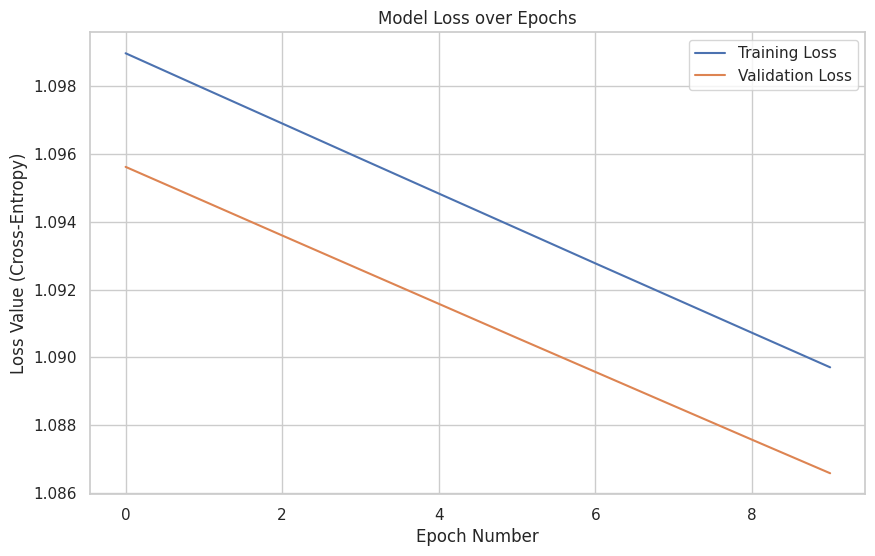

In [10]:
def build_model_tf(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(3, activation='softmax', input_shape=(input_shape,))
    ])
    
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    return model

model_tf = build_model_tf(X_train.shape[1])


X_train = np.array(X_train).astype('float32')
X_val = np.array(X_val).astype('float32')
X_test = np.array(X_test).astype('float32')

Y_train = np.array(Y_train).astype('int32')
Y_val = np.array(Y_val).astype('int32')
Y_test = np.array(Y_test).astype('int32')

history = model_tf.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, Y_val),
    verbose=1
)

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch Number')
plt.ylabel('Loss Value (Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()

---
### Step 5: Hyperparameter tuning

### <span style="color:chocolate">Exercise 7:</span> Choosing hyperparameters (10 points)

1. Fine-tune the **learning rate**, **number of epochs**, and **batch size** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). 

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (this should include the bias term);
3. The loss at the final epoch on both the training and validation datasets;
4. The percentage difference between the losses observed on the training and validation datasets.
5. Compare the training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

Epoch 1/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4940 - loss: 1.0443 - val_accuracy: 0.5961 - val_loss: 0.9990
Epoch 2/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6518 - loss: 0.9646 - val_accuracy: 0.7131 - val_loss: 0.9308
Epoch 3/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7279 - loss: 0.9023 - val_accuracy: 0.7187 - val_loss: 0.8782
Epoch 4/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7512 - loss: 0.8543 - val_accuracy: 0.7465 - val_loss: 0.8377
Epoch 5/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7632 - loss: 0.8171 - val_accuracy: 0.7493 - val_loss: 0.8065
Epoch 6/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7651 - loss: 0.7881 - val_accuracy: 0.7521 - val_loss: 0.7823
Epoch 7/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7651 - loss: 0.7654 - val_accuracy: 0.7521 - val_loss: 0.7632
Epoch 8/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7679 - loss: 0.7473 - val_accuracy: 0.7549 - val_loss:

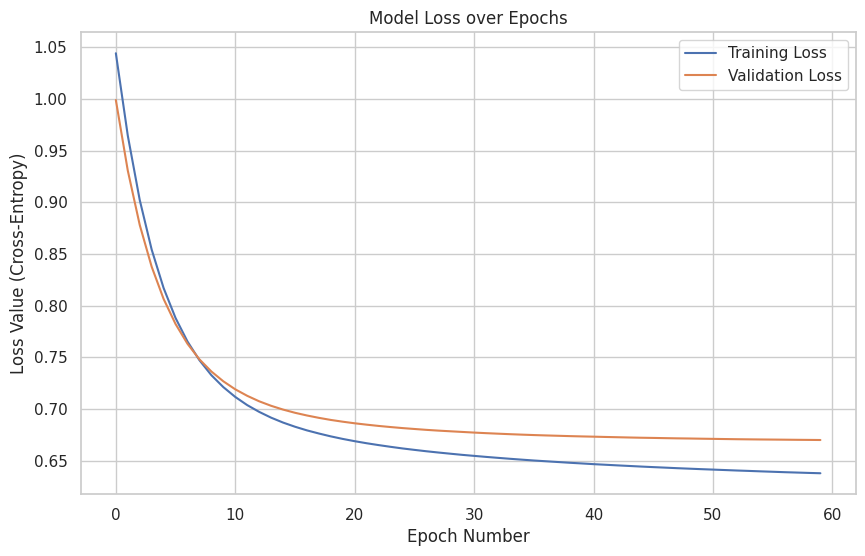

First five learned parameters (including a bias term): [ 0.24224715  0.24919906 -0.3527172   0.05621662 -0.0588095 ]
Final Training Loss: 0.6378946304321289
Final Validation Loss: 0.6700605750083923
Percentage Difference: 5.042516905099712


In [11]:
optimizer = tf.keras.optimizers.SGD(learning_rate=.01)
model_tf.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model_tf.fit(
    X_train, Y_train,
    epochs=60,
    batch_size=32,
    validation_data=(X_val, Y_val)
)

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch Number')
plt.ylabel('Loss Value (Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()


weights, biases = model_tf.layers[0].get_weights()
learned_parameters = np.append(weights.flatten()[:4], biases[0])
print(f"First five learned parameters (including a bias term): {learned_parameters}")

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
percent_diff = abs(final_train_loss - final_val_loss) / final_train_loss * 100

print(f"Final Training Loss: {final_train_loss}")
print(f"Final Validation Loss: {final_val_loss}")
print(f"Percentage Difference: {percent_diff}")

# TF model has a final validation loss of 0.6645211577415466 VS the baseline validation loss of 8.734812938309727, which means the TF model is singificantly better.

---
### Step 6: Evaluation and generalization

### <span style="color:chocolate">Exercise 8:</span> Compute metrics (10 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate aggregate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras. and the <span style="color:chocolate">np.max()</span> method available in NumPy.

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations.

In [12]:
train_prob = model_tf.predict(X_train)
test_prob = model_tf.predict(X_test)

train_predicted = np.argmax(train_prob, axis=1)
test_predicted = np.argmax(test_prob, axis=1)

train_accuracy = accuracy_score(Y_train, train_predicted)
test_accuracy = accuracy_score(Y_test, test_predicted)

print(f"Aggregate Training Accuracy: {train_accuracy}")
print(f"Aggregate Test Accuracy: {test_accuracy}")

# I have an aggregate training accuracy of approximately 0.7697307335190343 and a test accuracy of 0.8022284122562674, which are close enough that I feel good, especially since the model is better than the baseline model.

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Aggregate Training Accuracy: 0.7669452181987001
Aggregate Test Accuracy: 0.8022284122562674


### <span style="color:chocolate">Exercise 9:</span> Additional metrics (10 points)

Using the test dataset:

1. Plot the confusion matrix. Identify which class the model confuses the most.

2. Determine which class has the lowest precision. What is the precision? Which class is the largest source of false positives?

3. Determine which class has the lowest recall. What is the recall? Which class is the largest source of false negatives?

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


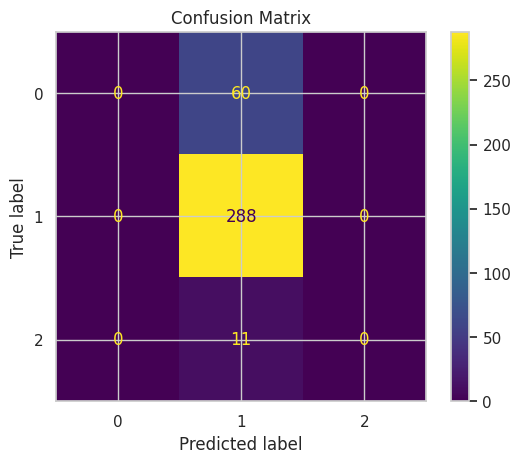

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.80      1.00      0.89       288
           2       0.00      0.00      0.00        11

    accuracy                           0.80       359
   macro avg       0.27      0.33      0.30       359
weighted avg       0.64      0.80      0.71       359



In [13]:
y_predicted_prob = model_tf.predict(X_test)
y_predicted = np.argmax(y_predicted_prob, axis=1)

cm = confusion_matrix(Y_test, y_predicted)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])

display.plot()
plt.title('Confusion Matrix')
plt.show()

report = classification_report(Y_test, y_predicted, labels=[0, 1, 2], output_dict=True)
print(classification_report(Y_test, y_predicted, labels=[0, 1, 2]))

# 1. The class that confuses the most is the medium cacao
# 2. Both the low and high caco has low precision, which is 0. medium cacao has the highest false positive
# 3. Both the low and high caco has low recall, which is 0. medium cacao has the highest false negative

----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Following the approach in Assignment 4 - Exercise 12, evaluate whether your model shows any signs of unfairness. Explain your findings and propose suggestions for improvement.

In [14]:
# YOUR CODE HERE